# Analysis
In this notebook Bebras tasks will be assigned CT tags. (1) <br>
Afterwards, we will start analysing model performances on these tasks (2) by
- Calculating frequency of correct answers (with and without retry)
- Calculate baseline performances for each model
- Compare models amongst each other
- Possibly check whether task perfromance is mediated by certain tags

# 1. Task properties
We will create a data frame which contains all the necessary information about the tasks, including the CT skills. 

In [1]:
#Packages etc
from pathlib import Path
import os
from collections import defaultdict
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

output_path =  Path(r"C:\Users\schul\Documents\uni\Master_Kogni\Praktikum\Tasks\output")


In [3]:

task_names = ["BeckyBee", "FlowerGarden", "StoneFactory", "Strawberries","TheGift", #7+8, easy
              "ClassroomSeating", "ColourTheFrog!", "OhridPearls", "Tic-Tac-Toe","WheatStorage", #7+8, medium
              "ConnectionOfIslands", "FavouriteMovie", "Mysteria", "Ordering1","UndergroundTrainNetwork", #7+8, hard
              "Cipher8", "InLove", "MarysNeighbours", "NutsAndBolts","RugWeaving", #9+10, easy
              "BeaverAI", "HangarCarousel", "OverlappingVillages", "ThePrinter", #9+10, medium
              "CollectingStones", "FavouriteGem", "FourTiles", "Maze", #9+10, hard
              "ColourfulCandles", "ListenAndWalk", "Lists", "MovieNight","Words", #11+12, easy
              "BeaverDam", "JumpingGame", "TreasureBox", #11+12, medium
              "BeaverDatabase", "BeaverGames", "Ordering2", "SeashellsAndPebbles","Virus"] #11+12, hard

# Will create an empty data frame and adapt the information manually
task_len = len(task_names)

data_empty = {"Task" : task_names,
              "Age": [None] * task_len, 
              "Difficulty" : [None] * task_len,
              "Decomposition": [True] * task_len, 
              "Pattern Recognition": [True] * task_len, 
              "Abstraction": [True] * task_len,
              "Modelling & Simulation" : [True] * task_len,
              "Algorithms": [True] * task_len, 
              "Evaluation": [True] * task_len 
              }

df_empty = pd.DataFrame(data_empty)




In [ ]:
df_empty = df_empty.transpose()
print(df_empty.head())

                              0             1             2             3   \
Task                    BeckyBee  FlowerGarden  StoneFactory  Strawberries   
Age                         None          None          None          None   
Difficulty                  None          None          None          None   
Decomposition               True          True          True          True   
Pattern Recognition         True          True          True          True   
Abstraction                 True          True          True          True   
Modelling & Simulation      True          True          True          True   
Algorithms                  True          True          True          True   
Evaluation                  True          True          True          True   

                             4                 5               6   \
Task                    TheGift  ClassroomSeating  ColourTheFrog!   
Age                        None              None            None   
Difficulty  

In [23]:
df_path = Path(r"C:\Users\schul\Documents\uni\Master_Kogni\Praktikum\Tasks")
df_empty.to_csv(df_path / "df_empty.csv", encoding = "utf-8", header = False)

I have manually filled in the categories and will load them here. Each category is listed and if a task fulfills this category, it is marked as TRUE 

In [ ]:
df_path = Path(r"C:\Users\schul\Documents\uni\Master_Kogni\Praktikum\Tasks")
df_categories = pd.read_csv(df_path / "df_categories.csv", sep = ";")
print(df_categories.head())

                     Task BeckyBee FlowerGarden StoneFactory Strawberries  \
0                     Age      7+8          7+8          7+8          7+8   
1              Difficulty     easy         easy         easy         easy   
2           Decomposition     TRUE         TRUE         TRUE         TRUE   
3     Pattern Recognition    FALSE         TRUE         TRUE        FALSE   
4             Abstraction    FALSE        FALSE         TRUE         TRUE   
5  Modelling & Simulation     TRUE         TRUE         TRUE         TRUE   
6              Algorithms     TRUE         TRUE         TRUE         TRUE   
7              Evaluation     TRUE         TRUE         TRUE         TRUE   

  TheGift ClassroomSeating ColourTheFrog! OhridPearls Tic-Tac-Toe  ...  \
0     7+8              7+8            7+8         7+8         7+8  ...   
1    easy           medium         medium      medium      medium  ...   
2    TRUE             TRUE           TRUE        TRUE        TRUE  ...   
3   FALSE 

**Accuracy Dataframe** <br>
We also need to save a dataframe which contains all the information about each models accuracy, we just can also save this in the previous data frame for simplicity reasons

In [ ]:
# Default values for now are 0

full_df = df_categories

models = ["Gemini_2.5","Gemini_2.5_retry",
          "Gpt_4o", "Gpt_4o_retry",
          "Gpt_5", "Gpt_5_retry"]

new_rows = []
for model in models:
    row = {"Task": model}
    for col in task_names:
        row[col] = 0
    new_rows.append(row)

models_df = pd.DataFrame(new_rows)
full_df = pd.concat([full_df, models_df], ignore_index= True)

print(full_df.head())

Now iterate through the JSON files and adapt the points based<br>
on task difficulty:<br> <br>
Easy: 6pts<br>
Medium: 9pts<br>
Hard: 12pts<br>
... if the answers are correct

In [ ]:
# Mini helper to determine points
def difficultyPoints(difficulty):
    if difficulty == "easy":
        return 6
    elif difficulty == "medium":
        return 9
    elif difficulty == "hard":
        return 12
        
age_groups = ["year_7_8", "year_9_10", "year_11_12"]
difficulties = ["easy", "medium", "hard"]
#reminder: task_names, models

for age_group in age_groups:
    for difficulty in difficulties:
        for model in models:
            # Handle retry naming and file matching
            is_retry = model.endswith("_retry")
            base_model = model.replace("_retry", "")

            # Folder path corresponds to the non-retry model
            model_folder = os.path.join(output_path, age_group, difficulty, base_model)
            if not os.path.exists(model_folder):
                continue

            for task in task_names:
                # Choose correct filename pattern
                if is_retry:
                    json_file = os.path.join(model_folder, f"{task}_{base_model}_retry.json")
                else:
                    json_file = os.path.join(model_folder, f"{task}_{base_model}.json")

                # Skip if JSON doesn’t exist
                if not os.path.exists(json_file):
                    continue

                # Read JSON safely
                try:
                    with open(json_file, "r") as f:
                        data = json.load(f)
                except json.JSONDecodeError:
                    print(f"Invalid JSON: {json_file}")
                    continue

                # Check correctness and assign points
                if data.get("is_correct") == True:
                    points = difficultyPoints(difficulty)
                    full_df.loc[full_df["Task"] == model, task] = points
                else:
                    # remains 0
                    pass

print(full_df.head())

                      Task BeckyBee FlowerGarden StoneFactory Strawberries  \
0                      Age      7+8          7+8          7+8          7+8   
1               Difficulty     easy         easy         easy         easy   
2            Decomposition     TRUE         TRUE         TRUE         TRUE   
3      Pattern Recognition    FALSE         TRUE         TRUE        FALSE   
4              Abstraction    FALSE        FALSE         TRUE         TRUE   
5   Modelling & Simulation     TRUE         TRUE         TRUE         TRUE   
6               Algorithms     TRUE         TRUE         TRUE         TRUE   
7               Evaluation     TRUE         TRUE         TRUE         TRUE   
8               Gemini_2.5        0            6            6            6   
9         Gemini_2.5_retry        0            0            0            0   
10                  Gpt_4o        0            6            6            0   
11            Gpt_4o_retry        0            0            0   

In [ ]:
print(full_df.head())
full_df.to_csv(df_path / "full_df.csv", encoding = "utf-8", header= True)

                      Task BeckyBee FlowerGarden StoneFactory Strawberries  \
0                      Age      7+8          7+8          7+8          7+8   
1               Difficulty     easy         easy         easy         easy   
2            Decomposition     TRUE         TRUE         TRUE         TRUE   
3      Pattern Recognition    FALSE         TRUE         TRUE        FALSE   
4              Abstraction    FALSE        FALSE         TRUE         TRUE   
5   Modelling & Simulation     TRUE         TRUE         TRUE         TRUE   
6               Algorithms     TRUE         TRUE         TRUE         TRUE   
7               Evaluation     TRUE         TRUE         TRUE         TRUE   
8               Gemini_2.5        0            6            6            6   
9         Gemini_2.5_retry        0            0            0            0   
10                  Gpt_4o        0            6            6            0   
11            Gpt_4o_retry        0            0            0   

# 2. Performance analysis 

In this step we will determine the accuracy based on model/ difficulty/ age/ categories etc.

In [2]:
#so that we don't have to re-run every piece of code
df_path = Path(r"C:\Users\schul\Documents\uni\Master_Kogni\Praktikum\Tasks")
full_df = pd.read_csv(df_path / "full_df.csv", sep = ",")
full_df = full_df.iloc[: , 1:]
full_df = full_df.set_index("Task")
full_df.loc[["Gemini_2.5", "Gemini_2.5_retry", "Gpt_4o", "Gpt_4o_retry", "Gpt_5", "Gpt_5_retry"]] = (
    full_df.loc[["Gemini_2.5", "Gemini_2.5_retry", "Gpt_4o", "Gpt_4o_retry", "Gpt_5", "Gpt_5_retry"]]
    .apply(pd.to_numeric, errors="coerce")
)

print(full_df.head())

                    BeckyBee FlowerGarden StoneFactory Strawberries TheGift  \
Task                                                                          
Age                      7+8          7+8          7+8          7+8     7+8   
Difficulty              easy         easy         easy         easy    easy   
Decomposition           TRUE         TRUE         TRUE         TRUE    TRUE   
Pattern Recognition    FALSE         TRUE         TRUE        FALSE   FALSE   
Abstraction            FALSE        FALSE         TRUE         TRUE    TRUE   

                    ClassroomSeating ColourTheFrog! OhridPearls Tic-Tac-Toe  \
Task                                                                          
Age                              7+8            7+8         7+8         7+8   
Difficulty                    medium         medium      medium      medium   
Decomposition                   TRUE           TRUE        TRUE        TRUE   
Pattern Recognition             TRUE          FALSE

In [3]:
print(full_df)

                       BeckyBee FlowerGarden StoneFactory Strawberries  \
Task                                                                     
Age                         7+8          7+8          7+8          7+8   
Difficulty                 easy         easy         easy         easy   
Decomposition              TRUE         TRUE         TRUE         TRUE   
Pattern Recognition       FALSE         TRUE         TRUE        FALSE   
Abstraction               FALSE        FALSE         TRUE         TRUE   
Modelling & Simulation     TRUE         TRUE         TRUE         TRUE   
Algorithms                 TRUE         TRUE         TRUE         TRUE   
Evaluation                 TRUE         TRUE         TRUE         TRUE   
Gemini_2.5                    0            6            6            6   
Gemini_2.5_retry              0            0            0            0   
Gpt_4o                        0            6            6            0   
Gpt_4o_retry                  0       

In [4]:
# Small helper function to calculate all points

def accuracyFor(model, age=None, difficulty=None):
    cols = full_df.columns

    # --- Age filter ---
    if age is None:
        age_mask = pd.Series(True, index=cols)
    elif isinstance(age, (list, tuple, set)):
        age_mask = full_df.loc["Age"].isin(age)
    else:
        age_mask = full_df.loc["Age"] == age

    # --- Difficulty filter ---
    if difficulty is None:
        diff_mask = pd.Series(True, index=cols)
    elif isinstance(difficulty, (list, tuple, set)):
        diff_mask = full_df.loc["Difficulty"].isin(difficulty)
    else:
        diff_mask = full_df.loc["Difficulty"] == difficulty

    # --- Apply mask and sum up points ---
    vals = full_df.loc[model, age_mask & diff_mask]
    return pd.to_numeric(vals, errors="coerce").sum()



In [ ]:
# Function tests
print(accuracyFor("Gpt_4o", age ="9+10", difficulty="medium"))
print(accuracyFor("Gpt_4o", age="7+8"))
print(accuracyFor("Gpt_4o", difficulty="medium"))
print(accuracyFor("Gpt_4o", age =["7+8","9+10"], difficulty="medium"))
print(accuracyFor("Gemini_2.5"))

9
39
27
18
225


**Plotting results**


In [6]:
# Reminder: Max achievable points: 366

# Accuracy values for each model + retry
model_vals = {"Gpt_4o": accuracyFor("Gpt_4o"),
              "Gpt_5": accuracyFor("Gpt_5"),
              "Gemini_2.5": accuracyFor("Gemini_2.5")}

model_retry_vals = {"Gpt_4o_retry": accuracyFor("Gpt_4o_retry") + accuracyFor("Gpt_4o"),
                    "Gpt_5_retry": accuracyFor("Gpt_5_retry") + accuracyFor("Gpt_5"),
                    "Gemini_2.5_retry": accuracyFor("Gemini_2.5_retry")+ accuracyFor("Gemini_2.5")}

print(model_vals)
print(model_retry_vals)

{'Gpt_4o': 81, 'Gpt_5': 312, 'Gemini_2.5': 225}
{'Gpt_4o_retry': 132, 'Gpt_5_retry': 312, 'Gemini_2.5_retry': 252}


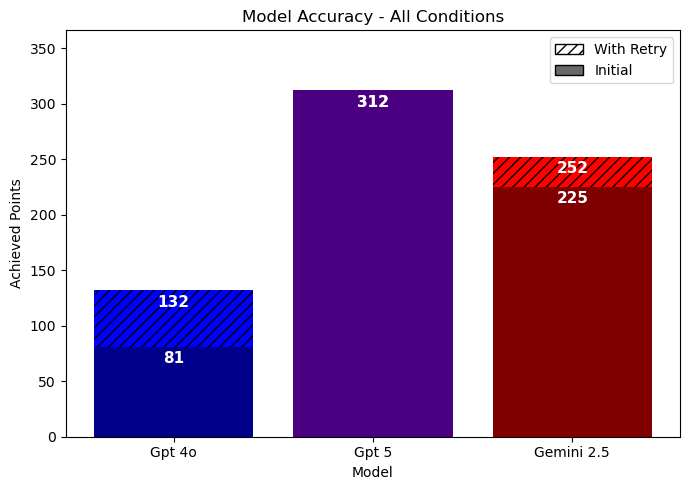

In [ ]:
# Plot the accuracy for each model + retry

labels = [m.replace("_", " ") for m in model_vals.keys()]

labels = [m.replace("_", " ") for m in model_vals.keys()]

base_colors  = ["darkblue", "indigo", "maroon"]
light_colors = ["blue", "orchid", "red"]

plt.figure(figsize=(7,5))

# Retry bars first (background)
plt.bar(labels, model_retry_vals.values(), color=light_colors, hatch="///", label="With Retry")

# Initial bars on top (foreground)
plt.bar(labels, model_vals.values(), color=base_colors, label="Initial")

# Add text labels
for i, val in enumerate(model_vals.values()):
    plt.text(i, val - 4 , str(val), ha="center", va="top", fontsize=11, 
             weight = "bold", color = "white")
for i, val in enumerate(model_retry_vals.values()):
    plt.text(i, val - 4, str(val), ha="center", va="top", fontsize=11, 
             weight = "bold", color = "white")

plt.ylabel("Achieved Points")
plt.xlabel("Model")
plt.title("Model Accuracy - All Conditions")
plt.ylim(0, 366)

# Custom legend without misleading colors
legend_handles = [
    mpatches.Patch(facecolor="none", edgecolor="black", hatch="///", label="With Retry"),
    mpatches.Patch(facecolor="dimgrey", edgecolor="black", label="Initial")
]
plt.legend(handles=legend_handles)

plt.tight_layout()
plt.show()

In [ ]:
# Accuracy values for each model + retry, save variables for future
Gpt4o_easy = accuracyFor("Gpt_4o", difficulty="easy")
Gpt4o_medium = accuracyFor("Gpt_4o", difficulty="medium")
Gpt4o_hard  = accuracyFor("Gpt_4o", difficulty="hard")
Gpt4o_easy_retry = accuracyFor("Gpt_4o_retry", difficulty="easy")
Gpt4o_medium_retry = accuracyFor("Gpt_4o_retry", difficulty="medium")
Gpt4o_hard_retry  = accuracyFor("Gpt_4o_retry", difficulty="hard")

Gpt5_easy = accuracyFor("Gpt_5", difficulty="easy")
Gpt5_medium = accuracyFor("Gpt_5", difficulty="medium")
Gpt5_hard  = accuracyFor("Gpt_5", difficulty="hard")
Gpt5_easy_retry = accuracyFor("Gpt_5_retry", difficulty="easy")
Gpt5_medium_retry = accuracyFor("Gpt_5_retry", difficulty="medium")
Gpt5_hard_retry  = accuracyFor("Gpt_5_retry", difficulty="hard")

Gemini_2_5_easy = accuracyFor("Gemini_2.5", difficulty="easy")
Gemini_2_5_medium = accuracyFor("Gemini_2.5", difficulty="medium")
Gemini_2_5_hard  = accuracyFor("Gemini_2.5", difficulty="hard")
Gemini_2_5_easy_retry = accuracyFor("Gemini_2.5_retry", difficulty="easy")
Gemini_2_5_medium_retry = accuracyFor("Gemini_2.5_retry", difficulty="medium")
Gemini_2_5_hard_retry  = accuracyFor("Gemini_2.5_retry", difficulty="hard")

# Max points each block
max_pts_easy = 30 + 30 + 30 # We use all easy tasks
max_pts_medium = 45 + 36 + 27 # We omitted 3 tasks
mx_pts_hard = 60 + 48 + 60 # We omitted 1 task

# Save in dict for plotting 
# We need to make the points comparable to one another, which is why we divide by max. points
model_vals_difficulty = {"Gpt_4o": [Gpt4o_easy / max_pts_easy,
                                    Gpt4o_medium / max_pts_medium,
                                    Gpt4o_hard / mx_pts_hard],
                         "Gpt_5": [Gpt5_easy / max_pts_easy,
                                    Gpt5_medium / max_pts_medium,
                                    Gpt5_hard / mx_pts_hard],
                         "Gemini_2.5": [Gemini_2_5_easy / max_pts_easy,
                                        Gemini_2_5_medium / max_pts_medium,
                                        Gemini_2_5_hard / mx_pts_hard]}

model_retry_vals_difficulty  = {"Gpt_4o_retry": [(Gpt4o_easy + Gpt4o_easy_retry) / max_pts_easy,
                                                 (Gpt4o_medium  + Gpt4o_medium_retry) / max_pts_medium,
                                                 (Gpt4o_hard + Gpt4o_hard_retry) / mx_pts_hard],
                                "Gpt_5_retry": [(Gpt5_easy + Gpt5_easy_retry) / max_pts_easy,
                                                 (Gpt5_medium  + Gpt5_medium_retry) / max_pts_medium,
                                                 (Gpt5_hard + Gpt5_hard_retry) / mx_pts_hard],
                                "Gemini_2.5_retry": [(Gemini_2_5_easy + Gemini_2_5_easy_retry) / max_pts_easy,
                                                 (Gemini_2_5_medium  + Gemini_2_5_medium_retry) / max_pts_medium,
                                                 (Gemini_2_5_hard + Gemini_2_5_hard_retry) / mx_pts_hard]}



print(model_vals_difficulty)
print(model_retry_vals_difficulty)

{'Gpt_4o': [0.3333333333333333, 0.25, 0.14285714285714285], 'Gpt_5': [0.8666666666666667, 0.8333333333333334, 0.8571428571428571], 'Gemini_2.5': [0.7333333333333333, 0.5833333333333334, 0.5714285714285714]}
{'Gpt_4o_retry': [0.6666666666666666, 0.3333333333333333, 0.21428571428571427], 'Gpt_5_retry': [0.8666666666666667, 0.8333333333333334, 0.8571428571428571], 'Gemini_2.5_retry': [0.8, 0.6666666666666666, 0.6428571428571429]}


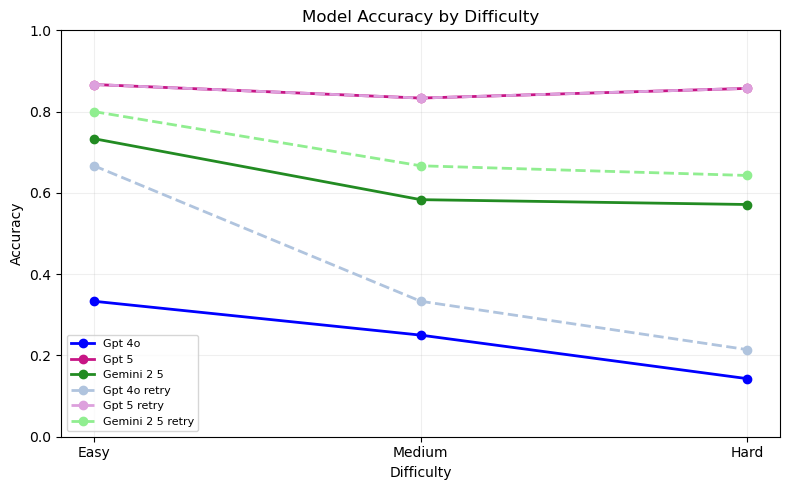

In [22]:
# Plot model x difficulty x accuracy

difficulties = ["Easy", "Medium", "Hard"]

# Colors matching your previous palette (same order: Gpt_4o, Gpt_5, Gemini)
base_colors  = ["blue", "mediumvioletred", "forestgreen"]
light_colors = ["lightsteelblue", "plum", "lightgreen"]  # used for dotted retry lines

plt.figure(figsize=(8,5))

# --- Plot initial model performance ---
for (model, vals), color in zip(model_vals_difficulty.items(), base_colors):
    label = model.replace("_", " ").replace(".", " ")
    plt.plot(difficulties, vals, marker="o", color=color, linestyle="-", linewidth=2, label=label)

# --- Plot retry performance (dotted lines) ---
for (model, vals), color in zip(model_retry_vals_difficulty.items(), light_colors):
    label = model.replace("_", " ").replace(".", " ") 
    plt.plot(difficulties, vals, marker="o", color=color, linestyle="--", linewidth=2, label=label)

plt.ylabel("Accuracy")
plt.xlabel("Difficulty")
plt.title("Model Accuracy by Difficulty")
plt.ylim(0,1)
plt.grid(alpha=0.2)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [24]:
# Plot model x age x accuracy

# Accuracy values for each model + retry, save variables for future
Gpt4o_years_7_8 = accuracyFor("Gpt_4o", age="7+8")
Gpt4o_years_9_10 = accuracyFor("Gpt_4o", age="9+10")
Gpt4o_years_11_12  = accuracyFor("Gpt_4o", age="11+12")
Gpt4o_years_7_8_retry = accuracyFor("Gpt_4o_retry", age="7+8")
Gpt4o_years_9_10_retry = accuracyFor("Gpt_4o_retry", age="9+10")
Gpt4o_years_11_12_retry  = accuracyFor("Gpt_4o_retry", age="11+12")

Gpt5_years_7_8 = accuracyFor("Gpt_5", age="7+8")
Gpt5_years_9_10 = accuracyFor("Gpt_5", age="9+10")
Gpt5_years_11_12  = accuracyFor("Gpt_5", age="11+12")
Gpt5_years_7_8_retry = accuracyFor("Gpt_5_retry", age="7+8")
Gpt5_years_9_10_retry = accuracyFor("Gpt_5_retry", age="9+10")
Gpt5_years_11_12_retry  = accuracyFor("Gpt_5_retry", age="11+12")

Gemini_2_5_years_7_8 = accuracyFor("Gemini_2.5", age="7+8")
Gemini_2_5_years_9_10 = accuracyFor("Gemini_2.5", age="9+10")
Gemini_2_5_years_11_12  = accuracyFor("Gemini_2.5", age="11+12")
Gemini_2_5_years_7_8_retry = accuracyFor("Gemini_2.5_retry", age="7+8")
Gemini_2_5_years_9_10_retry = accuracyFor("Gemini_2.5_retry", age="9+10")
Gemini_2_5_years_11_12_retry  = accuracyFor("Gemini_2.5_retry", age="11+12")

# Max points each block
max_pts_years_7_8 = 30 + 45 + 60 # We use all easy tasks
max_pts_years_9_10 = 30 + 36 + 48 # We omitted 2 tasks
mx_pts_years_11_12 = 30 + 27 + 60 # We omitted 2 task

# Save in dict for plotting 
# We need to make the points comparable to one another, which is why we divide by max. points
model_vals_ages = {"Gpt_4o": [Gpt4o_years_7_8 / max_pts_years_7_8,
                                    Gpt4o_years_9_10 / max_pts_years_9_10,
                                    Gpt4o_years_11_12 / mx_pts_years_11_12],
                         "Gpt_5": [Gpt5_years_7_8 / max_pts_years_7_8,
                                    Gpt5_years_9_10 / max_pts_years_9_10,
                                    Gpt5_years_11_12 / mx_pts_years_11_12],
                         "Gemini_2.5": [Gemini_2_5_years_7_8 / max_pts_years_7_8,
                                        Gemini_2_5_years_9_10 / max_pts_years_9_10,
                                        Gemini_2_5_years_11_12 / mx_pts_years_11_12]}

model_retry_vals_ages  = {"Gpt_4o_retry": [(Gpt4o_years_7_8 + Gpt4o_years_7_8_retry) / max_pts_years_7_8,
                                                 (Gpt4o_years_9_10 + Gpt4o_years_9_10_retry) / max_pts_years_9_10,
                                                 (Gpt4o_years_11_12 + Gpt4o_years_11_12_retry) / mx_pts_years_11_12],
                                "Gpt_5_retry": [(Gpt5_years_7_8 + Gpt5_years_7_8_retry) / max_pts_years_7_8,
                                                 (Gpt5_years_9_10  + Gpt5_years_9_10_retry) / max_pts_years_9_10,
                                                 (Gpt5_years_11_12 + Gpt5_years_11_12_retry) / mx_pts_years_11_12],
                                "Gemini_2.5_retry": [(Gemini_2_5_years_7_8 + Gemini_2_5_years_7_8_retry) / max_pts_years_7_8,
                                                 (Gemini_2_5_years_9_10  + Gemini_2_5_years_9_10_retry) / max_pts_years_9_10,
                                                 (Gemini_2_5_years_11_12 + Gemini_2_5_years_11_12_retry) / mx_pts_years_11_12]}



print(model_vals_ages)
print(model_retry_vals_ages)

{'Gpt_4o': [0.28888888888888886, 0.07894736842105263, 0.28205128205128205], 'Gpt_5': [0.9111111111111111, 0.7368421052631579, 0.8974358974358975], 'Gemini_2.5': [0.7333333333333333, 0.42105263157894735, 0.6666666666666666]}
{'Gpt_4o_retry': [0.4444444444444444, 0.23684210526315788, 0.38461538461538464], 'Gpt_5_retry': [0.9111111111111111, 0.7368421052631579, 0.8974358974358975], 'Gemini_2.5_retry': [0.7333333333333333, 0.5789473684210527, 0.7435897435897436]}


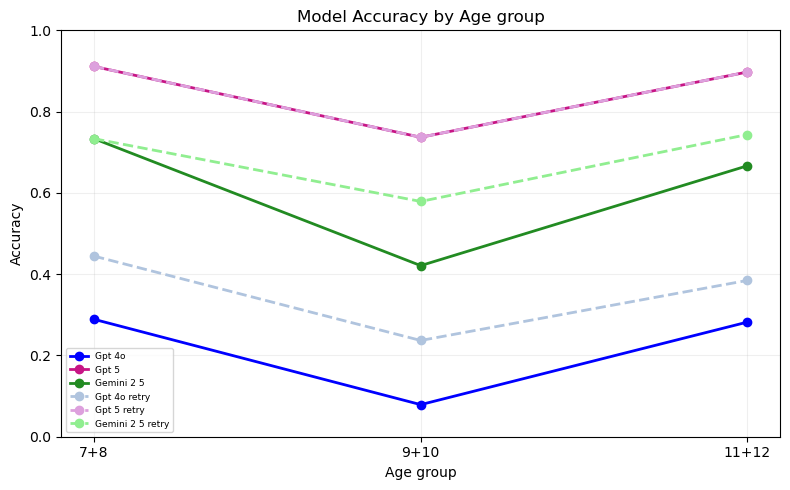

In [27]:
ages = ["7+8", "9+10", "11+12"]

# Colors matching the previous ones
base_colors  = ["blue", "mediumvioletred", "forestgreen"]
light_colors = ["lightsteelblue", "plum", "lightgreen"]  # used for dotted retry lines

plt.figure(figsize=(8,5))

# --- Plot initial model performance ---
for (model, vals), color in zip(model_vals_ages.items(), base_colors):
    label = model.replace("_", " ").replace(".", " ")
    plt.plot(ages, vals, marker="o", color=color, linestyle="-", linewidth=2, label=label)

# --- Plot retry performance (dotted lines) ---
for (model, vals), color in zip(model_retry_vals_ages.items(), light_colors):
    label = model.replace("_", " ").replace(".", " ") 
    plt.plot(ages, vals, marker="o", color=color, linestyle="--", linewidth=2, label=label)

plt.ylabel("Accuracy")
plt.xlabel("Age group")
plt.title("Model Accuracy by Age group")
plt.ylim(0,1)
plt.grid(alpha=0.2)
plt.legend(fontsize=6.5)
plt.tight_layout()
plt.show()